# Stratejik Sektör Sınıflandırması ve Hipotez Testleri (SNII x EIPI)

## 1. Giriş ve İki Boyutlu Çerçeve

Bu defter, `Strategic_Analysis_Prompt.md` talimatlarını uygulayarak ağ-tabanlı **SNII** (Structural
Network Importance Index) ile CGE-tabanlı **EIPI**'yi (Economy-wide Impact Performance Index)
birleştirir; (a) 62 sektörü dört stratejik kategoriye ayırır, (b) üretim ağı merkeziliğinin
genel-denge önemini ne ölçüde ve nasıl temsil ettiğine dair dört hipotezi (H1-H4) test eder.

**Bu katman yeni bir ağ veya CGE hesaplaması YAPMAZ** — yalnızca daha önce üretilmiş SNII, EIPI ve
CGE çıktılarını birleştirir, sınıflandırma ve hipotez testlerini bunlar üzerinde çalıştırır.

**Ne yapılıyor, neden iki eksen kullanılıyor:** Ana eksenler kasıtlı olarak **`SNII_DIM`** (boyut-nötr,
boyut-dengeli yapısal ağ önemi) ve **`EIPI_CH_size_controlled`** (kanal-dengeli, boyut-kontrollü
ekonomi-geneli etki performansı) olarak seçilmiştir — ikisi de **boyuttan (sektör büyüklüğünden)
arındırılmıştır**. Bu sayede iki-boyutlu karşılaştırma, sektör büyüklüğünü değil, **yapısal önem**
(ağdaki konum) ile **genel-denge etkinliği** (şokun ekonomiye ne kadar yayıldığı) arasındaki farkı
izole eder.

**Test edilecek dört hipotez:**
- **H1** — Ağ merkeziliği genel-denge önemiyle pozitif ilişkilidir (ama 1'in çok altında).
- **H2** — Bu ilişki eksiktir; yapısal merkezilik ile genel-denge önemi birbirinden ıraksayabilir.
- **H3** — Öngörülebilirlik CGE çıktısına göre heterojendir (reel büyüklükler ağdan daha iyi okunur).
- **H4** — Ağ konumu, salt sektör büyüklüğünün ötesinde sınırlı/özgül ek bilgi taşır.

### Kritik Veri Notu: Eksik `network_candidate_indicatorsV2.xlsx`

Talimatta beklenen girdi dosyalarından `network_candidate_indicatorsV2.xlsx`, bu klasörde **mevcut
değildir**. Yedi ham ağ göstergesi bunun yerine `../Analiz I/1_network_candidate_indicators.xlsx`
dosyasından (`coefficient_based_indicators` sayfası) alınmıştır — bu dosya, burada da bulunan ve
bayt-bayt aynı olduğu doğrulanmış `1-IntermediateInputs.xlsx` kaynağından üretilmiştir; yani
**aynı temel ağ verisi**, sadece "V2" adıyla yeniden dışa aktarılmamış hâlidir. Bu ikame,
`StrategicAnalysis.py` içinde de belgelenmiştir.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from StrategicAnalysis import StrategicAnalysis, PREDICTOR_SETS, CGE_OUTCOMES, RAW_NETWORK_INDICATORS, CATEGORY_LABELS

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10

CATEGORY_COLORS = {
    "Strategic Core Sectors": "#1b9e77",
    "Structurally Critical but Low-Transmission Sectors": "#d95f02",
    "Emerging Leverage Sectors": "#7570b3",
    "Peripheral Limited-Impact Sectors": "#999999",
}

print("Ortam hazir. Rastgelelik tohumu (seed) =", RANDOM_SEED)


Ortam hazir. Rastgelelik tohumu (seed) = 42


## 2. Veri Birleştirme (Section 1, Section 2)

**Ne:** Altı girdi dosyası (SNII sonuçları, EIPI sonuçları, ham ağ göstergeleri, CGE karşı-olgusal
sonuçlar, CGE bazal çözüm, ara-girdi matrisi) 62 sektör üzerinde birleştirilir. Sektör büyüklüğü
(**Domar ağırlığı**) `1-IntermediateInputs.xlsx`'in son sütunundan (toplam çıktı) türetilir — CGE
bazal dosyasından **değil**, çünkü o dosya yalnızca ekonomi-geneli agregatlar içerir.

**Neden:** H3 ve H4'ün büyüklük-kontrollü karşılaştırmaları için tek, tutarlı bir sektör-büyüklüğü
ölçütüne ihtiyaç vardır; bu ölçüt SNII/EIPI boyut-kontrolünde kullanılanla aynı kaynaktan
(`1-IntermediateInputs.xlsx`) gelmelidir ki karşılaştırmalar birbiriyle tutarlı olsun.


In [2]:
sa = StrategicAnalysis(
    snii_path="../01_SNII/3_snii_results.xlsx",
    eipi_path="../02_CGE_EIPI/4_eipi_results.xlsx",
    network_path="../01_SNII/1_network_candidate_indicators.xlsx",
    cge_path="../02_CGE_EIPI/2_cge_counterfactual_results.xlsx",
    io_path="../01_SNII/1-IntermediateInputs.xlsx",
    baseline_path="../02_CGE_EIPI/1_cge_baseline_solution.xlsx",
    snii_axis="SNII_DIM",
    eipi_axis="EIPI_CH_size_controlled",
)
panel = sa.build_panel()

print(f"Birlesik panel boyutu: {panel.shape}")
print(f"Sutunlar ({len(panel.columns)}): {list(panel.columns)}")
display(panel.head())

Birlesik panel boyutu: (62, 42)
Sutunlar (42): ['SNII_DIM', 'SNII_TOPSIS', 'SNII_PCA', 'SNII_AVG', 'D1_direct', 'D2_embeddedness', 'D3_bridge', 'D4_supply', 'SNII_DIM_size_controlled', 'EIPI_CH', 'EIPI_CH_size_controlled', 'EIPI_TOPSIS_size_controlled', 'EIPI_PCA_size_controlled', 'EIPI_AVG_size_controlled', 'C1_growth_spillover', 'C2_welfare_distribution', 'C3_external_balance', 'C4_price_stability', 'backward_linkage', 'forward_linkage', 'eigenvector_centrality', 'pagerank', 'betweenness_centrality', 'hub_score', 'authority_score', 'GDP_pct_change', 'Welfare_pct_change', 'ExportShare_pct_change', 'LaborIncomeShare_pct_change', 'Spillover_pct_change', 'ImportDependency_pct_change', 'CPI_pct_change', 'GDP_base', 'Welfare_base', 'ExportShare_base', 'LaborIncomeShare_base', 'Spillover_base', 'ImportDependency_base', 'CPI_base', 'total_output', 'domar_weight', 'log_output']


,SNII_DIM,SNII_TOPSIS,SNII_PCA,SNII_AVG,D1_direct,D2_embeddedness,D3_bridge,D4_supply,SNII_DIM_size_controlled,EIPI_CH,...,GDP_base,Welfare_base,ExportShare_base,LaborIncomeShare_base,Spillover_base,ImportDependency_base,CPI_base,total_output,domar_weight,log_output
sector,,,,,,,,,,,,,,,,,,,,,
sec1,0.243733,0.142506,0.235357,0.210863,0.376398,0.058999,0.018889,0.291722,0.178032,1.000000,...,27091.469065,0,26.943642,0.317655,0,16.387452,100,2865.510019,0.047284,7.960502
sec2,0.257724,0.095790,0.218301,0.186533,0.564518,0.132304,0.016667,0.063773,0.365816,0.013591,...,27091.469065,0,26.943642,0.317655,0,16.387452,100,69.435713,0.001146,4.240401
sec3,0.038477,0.033435,0.015823,0.023014,0.085779,0.146750,0.000000,0.054983,0.161915,0.003692,...,27091.469065,0,26.943642,0.317655,0,16.387452,100,69.261411,0.001143,4.237888
sec4,0.457653,0.212235,0.429876,0.373872,0.708907,0.083042,0.033333,0.398576,0.406695,0.056905,...,27091.469065,0,26.943642,0.317655,0,16.387452,100,1526.026343,0.025181,7.330422
sec5,0.461486,0.329047,0.483543,0.450279,0.300171,0.308273,0.345556,0.278421,0.376754,0.664594,...,27091.469065,0,26.943642,0.317655,0,16.387452,100,3114.057520,0.051386,8.043682


In [3]:
with pd.ExcelWriter("1_merged_index_panel.xlsx", engine="openpyxl") as writer:
    panel.to_excel(writer, sheet_name="merged_panel")
print("Kaydedildi: 1_merged_index_panel.xlsx")


Kaydedildi: 1_merged_index_panel.xlsx


## 3. Stratejik Sınıflandırma (Section 3)

**Ne:** Her sektör, dikey eksen `SNII_DIM` ve yatay eksen `EIPI_CH_size_controlled` olmak üzere,
her iki eksenin **ortalamasına** göre eşiklenerek dört kategoriye ayrılır:

- **Strategic Core Sectors** — SNII ≥ ortalama VE EIPI ≥ ortalama (hem yapısal hem etkili)
- **Structurally Critical but Low-Transmission Sectors** — SNII ≥ ortalama, EIPI < ortalama
  (ağda merkezi ama genel dengeye zayıf yayılan)
- **Emerging Leverage Sectors** — SNII < ortalama, EIPI ≥ ortalama (ağda çevresel ama etkili)
- **Peripheral Limited-Impact Sectors** — SNII < ortalama VE EIPI < ortalama

**Neden:** Bu dörtlü sınıflandırma, politika önceliklendirmesi için "hangi sektörler hem yapısal
hem etkili (asıl stratejik öncelik), hangileri sadece biri" sorusuna doğrudan yanıt verir. Ayrıca
dört karşılaştırma varyantı (boyut-dahil EIPI_CH, TOPSIS, PCA, AVG) ve medyan-eşik varyantı da
sağlamlık için hesaplanır (Section 3.2-3.3).


In [4]:
classes = sa.classify()
print("Ana siniflandirma (ortalama esik) dagilimi:")
print(classes["category_main_mean"].value_counts())
print()
print(f"Ortalama vs medyan esik ile kategori degistiren sektor sayisi: {sa.classification_meta['n_changed_mean_vs_median']} / 62")
print(f"Sinirda (borderline) sektor sayisi: {classes['borderline'].sum()} / 62")
display(classes.head(10))


Ana siniflandirma (ortalama esik) dagilimi:
category_main_mean
Structurally Critical but Low-Transmission Sectors    24
Emerging Leverage Sectors                             15
Peripheral Limited-Impact Sectors                     14
Strategic Core Sectors                                 9
Name: count, dtype: int64

Ortalama vs medyan esik ile kategori degistiren sektor sayisi: 8 / 62
Sinirda (borderline) sektor sayisi: 25 / 62


,category_main_mean,category_main_median,category_variant_snii_eipi_ch,category_variant_topsis,category_variant_pca,category_variant_avg,borderline
sector,,,,,,,
sec1,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec2,Emerging Leverage Sectors,Emerging Leverage Sectors,Peripheral Limited-Impact Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec3,Emerging Leverage Sectors,Emerging Leverage Sectors,Peripheral Limited-Impact Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec4,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,False
sec5,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,False
sec6,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec7,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Peripheral Limited-Impact Sectors,Structurally Critical but Low-Transmission Sec...,Peripheral Limited-Impact Sectors,True
sec8,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Peripheral Limited-Impact Sectors,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,False
sec9,Strategic Core Sectors,Strategic Core Sectors,Structurally Critical but Low-Transmission Sec...,Emerging Leverage Sectors,Strategic Core Sectors,Strategic Core Sectors,True


In [5]:
with pd.ExcelWriter("2_strategic_classification_table.xlsx", engine="openpyxl") as writer:
    classes.to_excel(writer, sheet_name="classification_table")
    pd.Series(sa.classification_meta, name="value").drop("variant_axes").to_frame().to_excel(writer, sheet_name="thresholds_meta")
print("Kaydedildi: 2_strategic_classification_table.xlsx")


Kaydedildi: 2_strategic_classification_table.xlsx


### Ana Sınıflandırma Dörtlü Grafiği

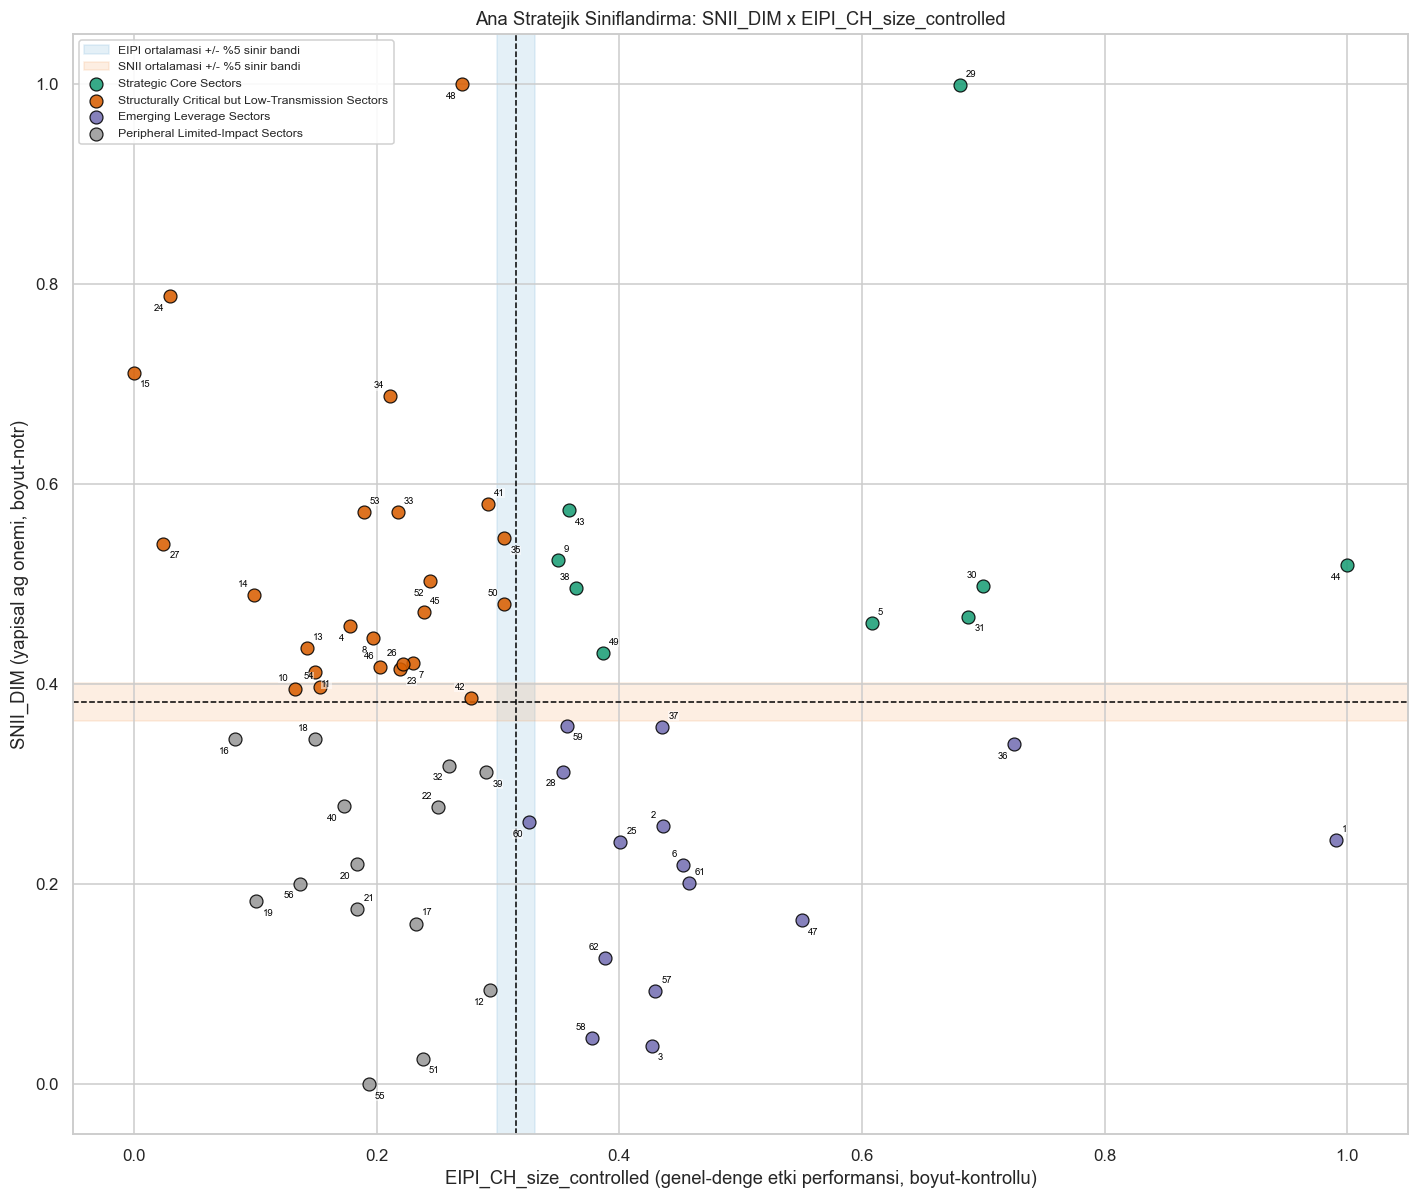

In [6]:
fig, ax = plt.subplots(figsize=(13, 11))
v_mean, h_mean = sa.classification_meta["v_mean"], sa.classification_meta["h_mean"]
band_fraction = 0.05
h_lower, h_upper = h_mean * (1 - band_fraction), h_mean * (1 + band_fraction)
v_lower, v_upper = v_mean * (1 - band_fraction), v_mean * (1 + band_fraction)

# Transparent +/-5% boundary bands around the empirical means.
ax.axvspan(h_lower, h_upper, color="#6BAED6", alpha=0.18, zorder=0, label="EIPI ortalamasi +/- %5 sinir bandi")
ax.axhspan(v_lower, v_upper, color="#F4A261", alpha=0.18, zorder=0, label="SNII ortalamasi +/- %5 sinir bandi")

for cat, color in CATEGORY_COLORS.items():
    mask = classes["category_main_mean"] == cat
    ax.scatter(panel.loc[mask, "EIPI_CH_size_controlled"], panel.loc[mask, "SNII_DIM"],
               color=color, label=cat, s=72, alpha=0.88, edgecolor="black", linewidth=0.8, zorder=3)

ax.axvline(h_mean, color="black", linestyle="--", linewidth=1)
ax.axhline(v_mean, color="black", linestyle="--", linewidth=1)

# Label all 62 observations with sector number only (sec29 -> 29).
for position, sector in enumerate(panel.index):
    sector_number = str(sector).replace("sec", "")
    dx = 4 if position % 2 == 0 else -4
    dy = 4 if (position // 2) % 2 == 0 else -5
    ax.annotate(sector_number,
                (panel.loc[sector, "EIPI_CH_size_controlled"], panel.loc[sector, "SNII_DIM"]),
                fontsize=6.2, color="black", fontweight="medium",
                ha="left" if dx > 0 else "right", va="bottom" if dy > 0 else "top",
                xytext=(dx, dy), textcoords="offset points", zorder=4,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.52, pad=0.15))

ax.set_xlabel("EIPI_CH_size_controlled (genel-denge etki performansi, boyut-kontrollu)")
ax.set_ylabel("SNII_DIM (yapisal ag onemi, boyut-notr)")
ax.set_title("Ana Stratejik Siniflandirma: SNII_DIM x EIPI_CH_size_controlled")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("8_classification_scatter_main.png", dpi=300, bbox_inches="tight")
plt.show()


**Yorum:** Dörtlü grafikteki her nokta bir sektörü temsil eder; kesikli çizgiler her eksenin
ortalama eşiğini gösterir. Sağ-üst çeyrekteki (Strategic Core) sektörler hem ağda merkezi hem de
genel dengede güçlü yayılım yaratan sektörlerdir — politika önceliklendirmesinde en yüksek getiriyi
sunan grup budur.


### Varyant Sınıflandırmaları (Section 3.2)

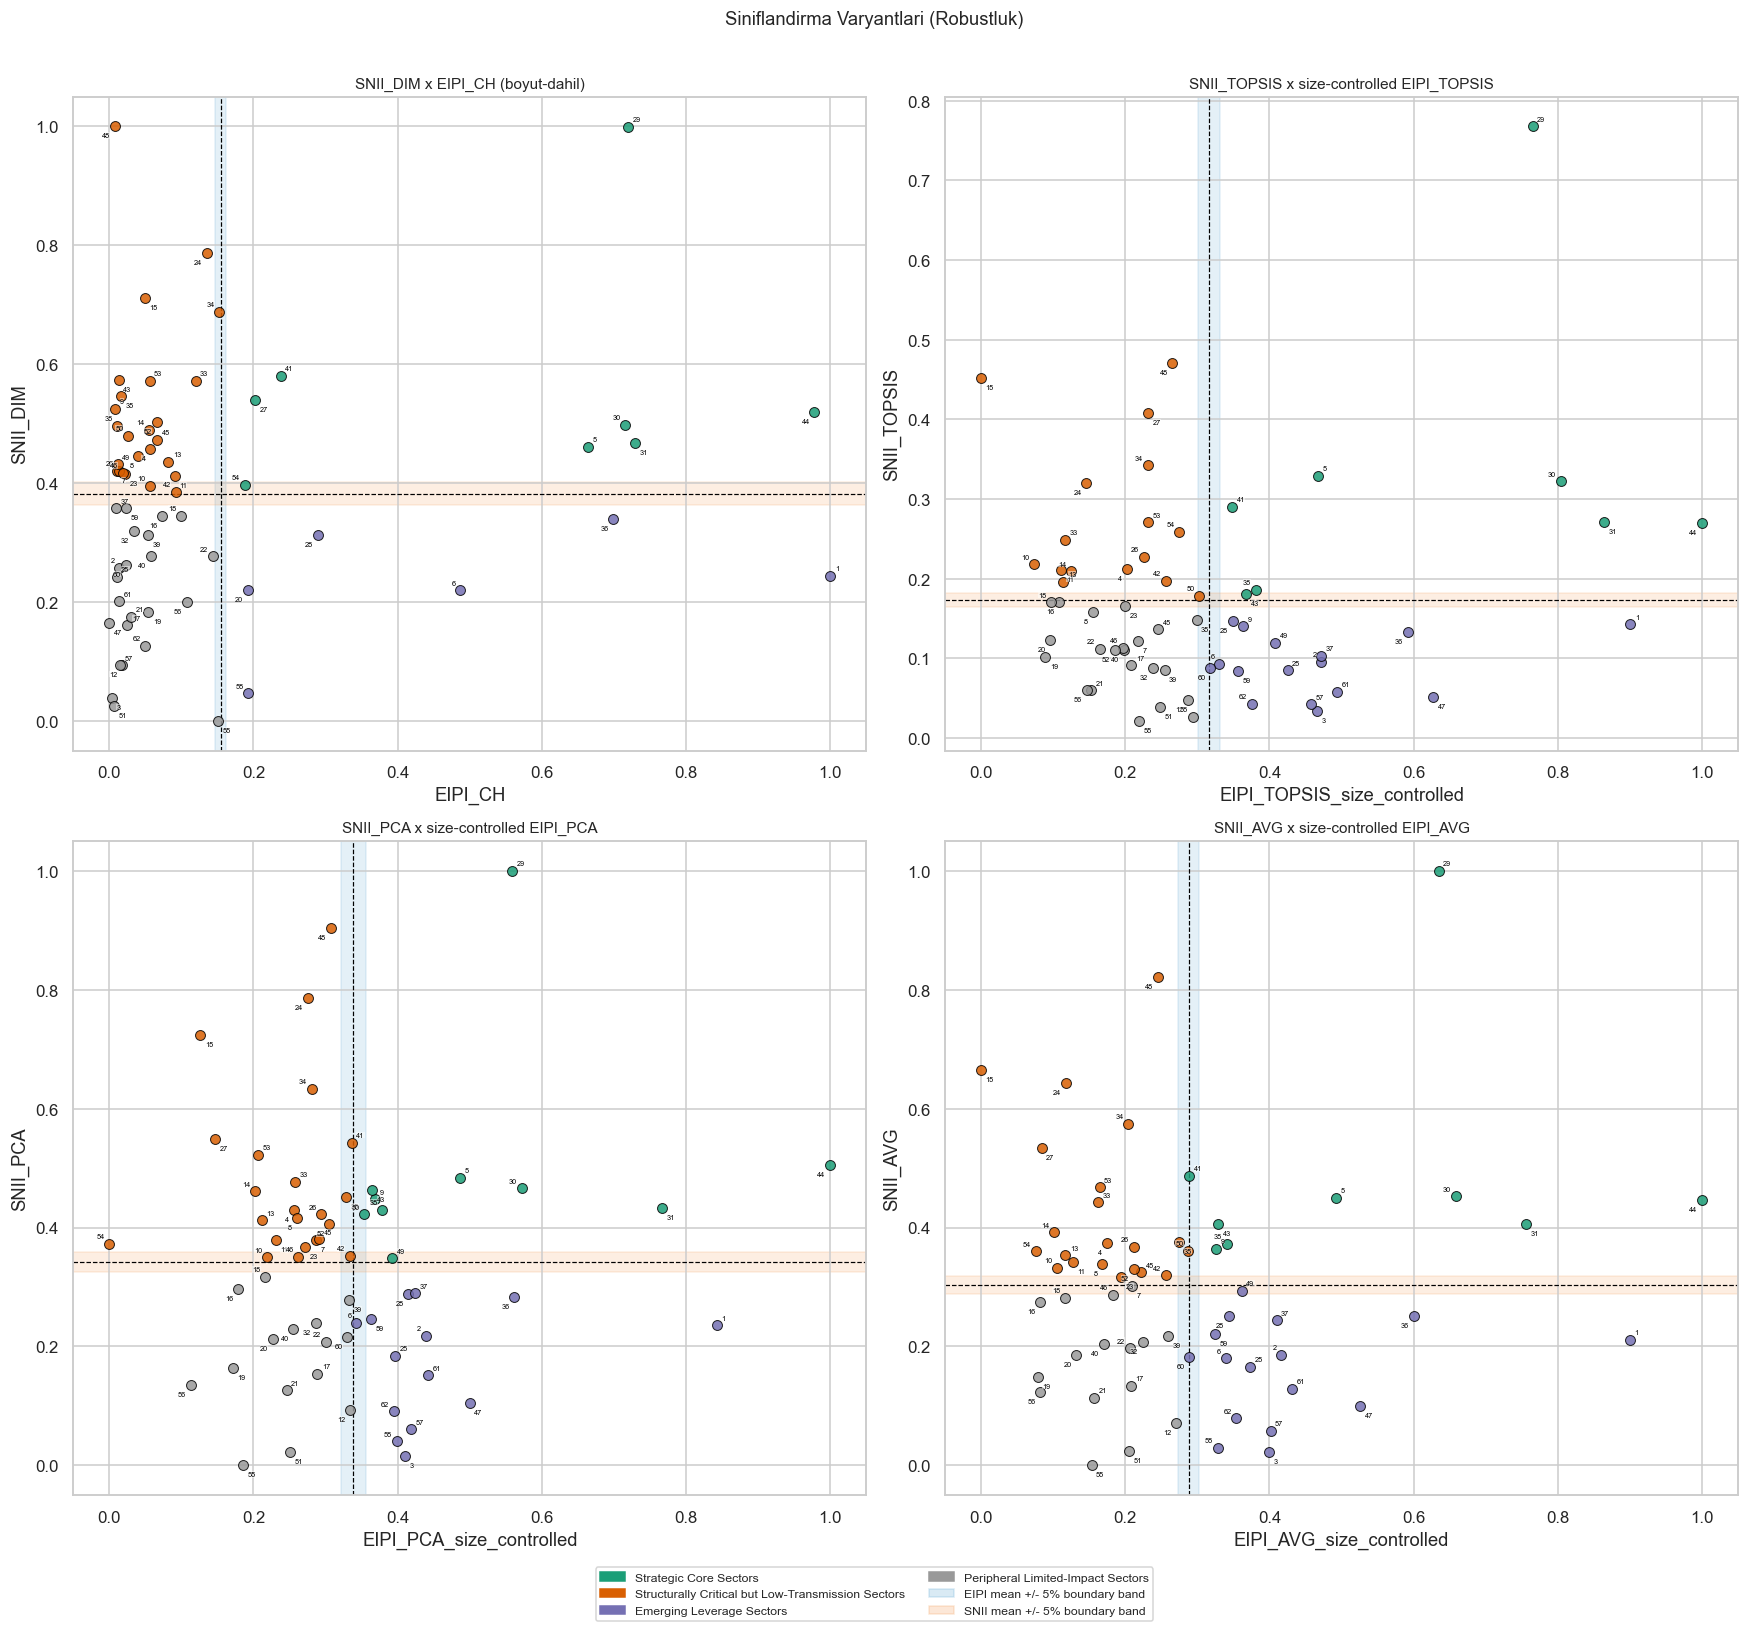

In [7]:
variant_defs = [
    ("category_variant_snii_eipi_ch", "SNII_DIM", "EIPI_CH", "SNII_DIM x EIPI_CH (boyut-dahil)"),
    ("category_variant_topsis", "SNII_TOPSIS", "EIPI_TOPSIS_size_controlled", "SNII_TOPSIS x size-controlled EIPI_TOPSIS"),
    ("category_variant_pca", "SNII_PCA", "EIPI_PCA_size_controlled", "SNII_PCA x size-controlled EIPI_PCA"),
    ("category_variant_avg", "SNII_AVG", "EIPI_AVG_size_controlled", "SNII_AVG x size-controlled EIPI_AVG"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (col, v_col, h_col, title) in zip(axes.flat, variant_defs):
    vv, hh = panel[v_col], panel[h_col]
    v_mean, h_mean = vv.mean(), hh.mean()
    v_lower, v_upper = v_mean * 0.95, v_mean * 1.05
    h_lower, h_upper = h_mean * 0.95, h_mean * 1.05
    ax.axvspan(h_lower, h_upper, color="#6BAED6", alpha=0.18, zorder=0)
    ax.axhspan(v_lower, v_upper, color="#F4A261", alpha=0.18, zorder=0)
    for cat, color in CATEGORY_COLORS.items():
        mask = classes[col] == cat
        ax.scatter(hh[mask], vv[mask], color=color, s=42, alpha=0.85, edgecolor="black", linewidth=0.65, zorder=3)
    ax.axvline(h_mean, color="black", linestyle="--", linewidth=0.8, zorder=2)
    ax.axhline(v_mean, color="black", linestyle="--", linewidth=0.8, zorder=2)
    for position, sector in enumerate(panel.index):
        sector_number = str(sector).replace("sec", "")
        dx = 3 if position % 2 == 0 else -3
        dy = 3 if (position // 2) % 2 == 0 else -4
        ax.annotate(sector_number, (hh.loc[sector], vv.loc[sector]),
                    fontsize=4.8, color="black", fontweight="medium",
                    ha="left" if dx > 0 else "right", va="bottom" if dy > 0 else "top",
                    xytext=(dx, dy), textcoords="offset points", zorder=4,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.48, pad=0.10))
    ax.set_xlabel(h_col); ax.set_ylabel(v_col); ax.set_title(title, fontsize=10)

fig.suptitle("Siniflandirma Varyantlari (Robustluk)", y=1.01)
handles = [mpatches.Patch(color=c, label=l) for l, c in CATEGORY_COLORS.items()]
handles += [mpatches.Patch(color="#6BAED6", alpha=0.25, label="EIPI mean +/- 5% boundary band"),
            mpatches.Patch(color="#F4A261", alpha=0.25, label="SNII mean +/- 5% boundary band")]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04), fontsize=8)
plt.tight_layout()
plt.savefig("9_classification_scatter_variants.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. H1 — Pozitif İlişki Hipotezi (Section 4, H1)

**Ne:** (a) `SNII_DIM` ile birincil EIPI hedefi arasındaki Spearman/Pearson korelasyonu; (b) yedi ham
ağ göstergesinin her biri ile EIPI hedefi arasındaki korelasyon; (c) her ağ göstergesi ile her CGE
çıktısı arasındaki 7x7 korelasyon matrisi.

**Neden:** H1, ağ merkeziliğinin genel-denge önemiyle **pozitif ama tam olmayan** bir ilişki
taşıyabileceğini öne sürer -- ama bu bir varsayım değil, test edilecek bir hipotezdir. Bivariate
korelasyonlarda çoklu-bağlantı sorunu yoktur, bu yüzden burada tüm yedi ham gösterge (dört boyut
alt-skoru değil) kullanılır — betimleyici katmanda en yorumlanabilir düzey budur. Aşağıdaki sonuç,
verinin fiilen gösterdiği yönü ve gücü -- pozitif de çıksa, zayıf/anlamsız de çıksa -- olduğu gibi
raporlar.


In [8]:
h1 = sa.test_h1()
print("H1(a): SNII_DIM - EIPI_CH_size_controlled iliskisi:")
display(h1["headline"].to_frame())

print()
print("H1(b): Yedi ham ag gostergesi - EIPI hedefi iliskisi:")
display(h1["metric_vs_eipi"].round(4))

rho = h1["headline"]["spearman_rho"]
p_val = h1["headline"]["spearman_p"]
print()
if rho > 0.05 and p_val < 0.05:
    print(f"BULGU: SNII_DIM-EIPI Spearman korelasyonu = {rho:.3f} (p={p_val:.3f}) -- pozitif ve "
          f"istatistiksel olarak anlamli, 1'in belirgin altinda. H1 bu veri setinde destekleniyor.")
elif abs(rho) <= 0.05 or p_val >= 0.05:
    print(f"BULGU: SNII_DIM-EIPI Spearman korelasyonu = {rho:.3f} (p={p_val:.3f}) -- istatistiksel "
          f"olarak sifirdan ayirt edilemiyor (anlamli degil). H1'in 'pozitif iliski' beklentisi bu "
          f"veri setinde ACIKCA DESTEKLENMIYOR; iliski neredeyse yok denecek kadar zayif. Bu, H2'nin "
          f"(yapisal merkezilik ile genel-denge onemi ayrisabilir) daha da guclu bir kaniti olarak okunmalidir.")
else:
    print(f"BULGU: SNII_DIM-EIPI Spearman korelasyonu = {rho:.3f} (p={p_val:.3f}) -- NEGATIF. "
          f"H1'in yonlu beklentisi bu veri setinde desteklenmiyor; ag merkeziligi ile boyut-kontrollu "
          f"genel-denge etkisi arasinda ters yonlu (zayif de olsa) bir iliski gozlemleniyor. Bu, "
          f"H2'nin ıraksama tezini guclendiren carpici bir bulgudur ve asagida H2'de detaylandirilacaktir.")


H1(a): SNII_DIM - EIPI_CH_size_controlled iliskisi:


,SNII_DIM_vs_EIPI_CH_size_controlled
spearman_rho,-0.135051
spearman_p,0.295306
pearson_r,-0.044240
pearson_p,0.732786



H1(b): Yedi ham ag gostergesi - EIPI hedefi iliskisi:


,spearman_rho,spearman_p,pearson_r,pearson_p
indicator,,,,
backward_linkage,-0.1357,0.2929,-0.1299,0.3142
forward_linkage,-0.1970,0.1249,-0.1860,0.1478
eigenvector_centrality,0.0110,0.9327,-0.0213,0.8698
pagerank,0.2082,0.1044,0.0607,0.6394
betweenness_centrality,-0.0996,0.4410,0.1439,0.2644
hub_score,-0.3356,0.0077,-0.0984,0.4467
authority_score,-0.1785,0.1652,-0.1289,0.3182



BULGU: SNII_DIM-EIPI Spearman korelasyonu = -0.135 (p=0.295) -- istatistiksel olarak sifirdan ayirt edilemiyor (anlamli degil). H1'in 'pozitif iliski' beklentisi bu veri setinde ACIKCA DESTEKLENMIYOR; iliski neredeyse yok denecek kadar zayif. Bu, H2'nin (yapisal merkezilik ile genel-denge onemi ayrisabilir) daha da guclu bir kaniti olarak okunmalidir.


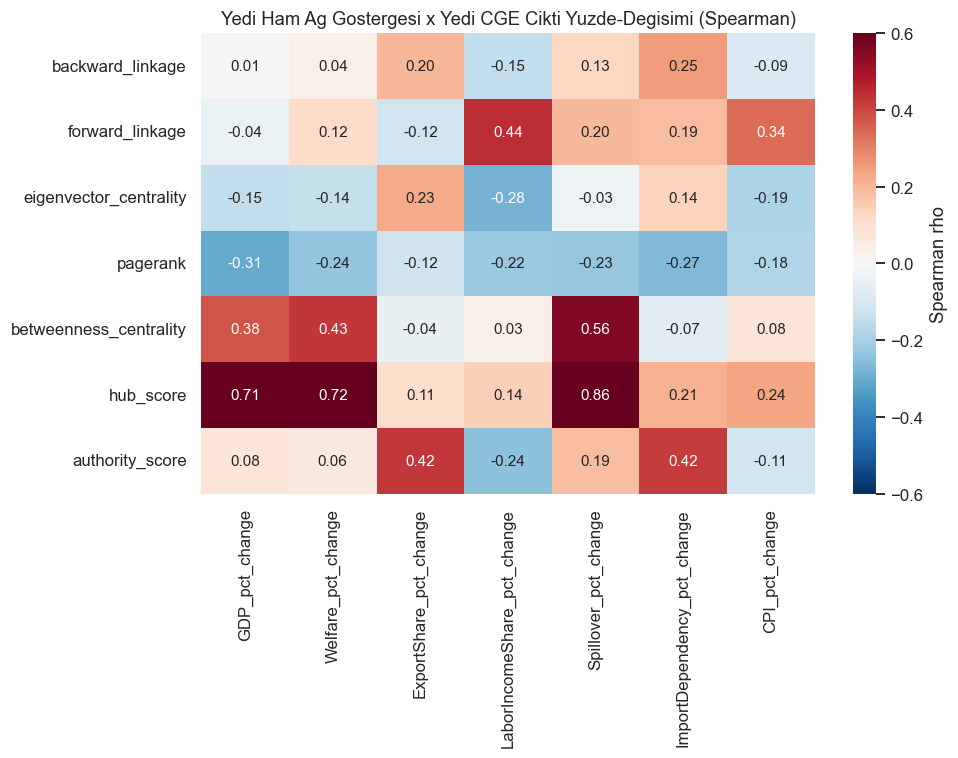

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(h1["metric_vs_outcome_rho"].astype(float), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.6, vmax=0.6, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Yedi Ham Ag Gostergesi x Yedi CGE Cikti Yuzde-Degisimi (Spearman)")
plt.tight_layout()
plt.savefig("10_snii_eipi_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
with pd.ExcelWriter("3_H1_H2_correlations.xlsx", engine="openpyxl") as writer:
    h1["headline"].to_frame("value").to_excel(writer, sheet_name="H1_headline")
    h1["metric_vs_eipi"].to_excel(writer, sheet_name="H1_metric_vs_eipi")
    h1["metric_vs_outcome_rho"].to_excel(writer, sheet_name="H1_metric_vs_outcome_rho")
    h1["metric_vs_outcome_p"].to_excel(writer, sheet_name="H1_metric_vs_outcome_p")
print("H1 bolumu 3_H1_H2_correlations.xlsx'e yazildi (H2 asagida eklenecek).")


H1 bolumu 3_H1_H2_correlations.xlsx'e yazildi (H2 asagida eklenecek).


## 5. H2 — Işaksama ve Sürpriz Sektörler (Section 4, H2)

**Ne:** Ana sınıflandırmadaki **köşegen-dışı** (off-diagonal) sektörlerin sayısı (Emerging Leverage +
Structurally Critical but Low-Transmission) hesaplanır; en çok ıraksayan sektörler (yüksek SNII/düşük
EIPI ve tersi) ham CGE göstergeleriyle (ithalat bağımlılığı, refah, yayılma) birlikte tablo hâline
getirilerek mekanizma tartışılır.

**Neden:** H1'in ilişkinin tam olmadığını göstermesi yetmez; H2, bu eksikliğin **nerede ve neden**
ortaya çıktığını somutlaştırır — örneğin ağda merkezi bir sektörün üretimi büyük ölçüde ithal
girdiye dayanıyorsa (yüksek ImportDependency), verimlilik şoku büyük ölçüde yurt dışına "sızar" ve
düşük EIPI ile sonuçlanır.


In [11]:
h2 = sa.test_h2()
print(f"Kosegen-disi sektor sayisi: {h2['n_off_diagonal']} / {h2['n_total']} ({h2['off_diagonal_share']*100:.1f}%)")
print()
print("Yuksek SNII / dusuk EIPI (yapisal olarak merkezi ama zayif aktarim):")
display(h2["high_snii_low_eipi"].round(3))
print()
print("Dusuk SNII / yuksek EIPI (yapisal olarak cevresel ama etkili):")
display(h2["low_snii_high_eipi"].round(3))


Kosegen-disi sektor sayisi: 39 / 62 (62.9%)

Yuksek SNII / dusuk EIPI (yapisal olarak merkezi ama zayif aktarim):


,SNII_DIM,EIPI_CH_size_controlled,GDP_pct_change,Welfare_pct_change,ExportShare_pct_change,LaborIncomeShare_pct_change,Spillover_pct_change,ImportDependency_pct_change,CPI_pct_change,divergence_percentile_gap
sector,,,,,,,,,,
sec15,0.711,0.000,0.130,0.049,0.210,0.008,0.123,0.090,0.114,0.935
sec24,0.788,0.030,0.218,0.164,-0.279,0.240,0.204,0.036,0.114,0.919
sec27,0.541,0.024,0.557,0.043,-0.089,-0.010,0.407,-0.014,0.308,0.806
sec14,0.489,0.099,0.132,0.054,-0.031,-0.001,0.130,0.022,0.093,0.661
sec53,0.572,0.189,0.129,0.068,-0.128,-0.150,0.115,0.003,0.075,0.613
sec34,0.688,0.211,0.165,0.128,-0.001,0.021,0.135,0.004,0.060,0.597
sec33,0.572,0.218,0.071,0.069,0.090,-0.030,0.040,0.003,-0.047,0.516
sec48,1.000,0.270,0.023,0.016,-0.024,-0.009,0.020,-0.004,0.013,0.484



Dusuk SNII / yuksek EIPI (yapisal olarak cevresel ama etkili):


,SNII_DIM,EIPI_CH_size_controlled,GDP_pct_change,Welfare_pct_change,ExportShare_pct_change,LaborIncomeShare_pct_change,Spillover_pct_change,ImportDependency_pct_change,CPI_pct_change,divergence_percentile_gap
sector,,,,,,,,,,
sec3,0.038,0.427,0.018,0.004,0.022,-0.011,-0.006,-0.003,0.004,-0.742
sec47,0.164,0.550,0.010,0.000,-0.001,-0.007,0.003,-0.001,0.004,-0.742
sec57,0.093,0.429,0.019,0.012,-0.011,-0.009,0.007,-0.005,-0.008,-0.726
sec1,0.244,0.990,0.617,0.638,-0.300,0.189,0.188,-0.347,-0.289,-0.710
sec58,0.046,0.377,0.122,0.115,-0.096,0.043,0.025,-0.039,-0.101,-0.661
sec61,0.201,0.457,0.014,0.013,-0.005,0.001,0.008,-0.000,-0.009,-0.661
sec62,0.126,0.388,0.037,0.037,-0.023,-0.005,0.012,-0.009,-0.032,-0.645
sec6,0.219,0.452,0.280,0.295,0.558,-0.108,0.046,0.059,-0.156,-0.629


**Yorum:** Yüksek-SNII/düşük-EIPI grubundaki sektörlerde tipik olarak **yüksek
`ImportDependency_pct_change`** ve/veya zayıf `Spillover_pct_change`/`Welfare_pct_change` görülüyorsa,
bu, sektörün ağdaki merkezi konumuna rağmen verimlilik kazancının büyük ölçüde ithalat sızıntısı
yoluyla ekonomiden çıktığına işaret eder. Düşük-SNII/yüksek-EIPI grubu ise ağda "görünmez" olsa da
(örn. düşük ara-girdi bağlantısı) hanehalkı tüketim sepetinde büyük ağırlığı olan veya güçlü ihracat
tepkisi veren sektörleri temsil edebilir.


In [12]:
with pd.ExcelWriter("3_H1_H2_correlations.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    h1["headline"].to_frame("value").to_excel(writer, sheet_name="H1_headline")
    h1["metric_vs_eipi"].to_excel(writer, sheet_name="H1_metric_vs_eipi")
    h1["metric_vs_outcome_rho"].to_excel(writer, sheet_name="H1_metric_vs_outcome_rho")
    h1["metric_vs_outcome_p"].to_excel(writer, sheet_name="H1_metric_vs_outcome_p")
    pd.Series({"n_off_diagonal": h2["n_off_diagonal"], "n_total": h2["n_total"],
               "off_diagonal_share": h2["off_diagonal_share"]}).to_frame("value").to_excel(writer, sheet_name="H2_summary")
    h2["high_snii_low_eipi"].to_excel(writer, sheet_name="H2_high_snii_low_eipi")
    h2["low_snii_high_eipi"].to_excel(writer, sheet_name="H2_low_snii_high_eipi")
print("Kaydedildi: 3_H1_H2_correlations.xlsx (H1 + H2 tum sayfalar)")


Kaydedildi: 3_H1_H2_correlations.xlsx (H1 + H2 tum sayfalar)


## 6. H3 — Çıktıya Göre Heterojenlik (Section 4, H3; Section 2.1)

**Ne:** Yedi CGE `pct_change` çıktısının her biri, **dört SNII boyut alt-skorundan**
(`D1_direct, D2_embeddedness, D3_bridge, D4_supply` — birincil tahminci seti) elastic-net ile ve
**leave-one-out çapraz doğrulama (LOOCV)** kullanılarak örneklem-dışı tahmin edilir; performans
`LOOCV R²` ve `Spearman(tahmin, gerçek)` ile raporlanır. Dejenere (neredeyse sabit) tahminler için
sıralama korelasyonu **raporlanmaz** — sadece R² (≈0 veya negatif) ve "öngörülebilir sinyal yok"
bayrağı verilir (Section 2.1).

**Neden dört boyut alt-skoru (yedi ham gösterge değil):** Yedi ham gösterge birbiriyle güçlü
kollineer (ör. eigenvector-backward ρ≈0.95). n=62 gibi küçük bir örneklemde yedi kollineer
tahminciyi bir modele sokmak aşırı-uyuma (overfitting) yol açar ve anlamsız, genellikle negatif
örneklem-dışı R² üretir. Dört boyut alt-skoru neredeyse ortogonal ve yedeklilik-kontrollüdür —
SNII'nin bizzat nasıl kurulduğuyla tutarlıdır ve daha temiz, yorumlanabilir çok-değişkenli sonuçlar
verir. Sağlamlık için seçilmiş-5 (retained-5), ham-7 ve tek başına `SNII_DIM` ile de tekrarlanır.


In [13]:
h3 = sa.test_h3()
print("H3 sonuclari (tum tahminci setleri x tum ciktilar):")
display(h3.round(4))


H3 sonuclari (tum tahminci setleri x tum ciktilar):


loocv_r2  spearman_rho  \
predictor_set       outcome                                               
dimension_subscores GDP_pct_change                 0.3246        0.6985   
                    Welfare_pct_change             0.0431        0.5862   
                    ExportShare_pct_change        -0.0331           NaN   
                    LaborIncomeShare_pct_change    0.0016        0.2501   
                    Spillover_pct_change           0.4456        0.7604   
                    ImportDependency_pct_change   -0.0801       -1.0000   
                    CPI_pct_change                -0.0331           NaN   
retained_5          GDP_pct_change                 0.2873        0.6979   
                    Welfare_pct_change            -0.1089        0.4188   
                    ExportShare_pct_change        -0.0331           NaN   
                    LaborIncomeShare_pct_change   -0.0302        0.1820   
                    Spillover_pct_change           0.4088        0.7315   
                    ImportDependency_pct_change   -0.0778       -0.9997   
                    CPI_pct_change                -0.0412           NaN   
all_7_raw           GDP_pct_change                 0.2696        0.6957   
                    Welfare_pct_change            -0.1088        0.4188   
                    ExportShare_pct_change        -0.1399       -1.0000   
                    LaborIncomeShare_pct_change   -0.0246        0.1989   
                    Spillover_pct_change           0.3685        0.7207   
                    ImportDependency_pct_change   -0.0250        0.2378   
                    CPI_pct_change                -0.0387           NaN   
SNII_DIM_only       GDP_pct_change                -0.0601       -0.7529   
                    Welfare_pct_change            -0.0373        0.1623   
                    ExportShare_pct_change        -0.0331           NaN   
                    LaborIncomeShare_pct_change   -0.0287        0.0119   
                    Spillover_pct_change           0.0994        0.3571   
                    ImportDependency_pct_change   -0.0331           NaN   
                    CPI_pct_change                -0.0331           NaN   

                                                 spearman_p  degenerate  \
predictor_set       outcome                                               
dimension_subscores GDP_pct_change                   0.0000       False   
                    Welfare_pct_change               0.0000       False   
                    ExportShare_pct_change              NaN        True   
                    LaborIncomeShare_pct_change      0.0499       False   
                    Spillover_pct_change             0.0000       False   
                    ImportDependency_pct_change      0.0000       False   
                    CPI_pct_change                      NaN        True   
retained_5          GDP_pct_change                   0.0000       False   
                    Welfare_pct_change               0.0007       False   
                    ExportShare_pct_change              NaN        True   
                    LaborIncomeShare_pct_change      0.1568       False   
                    Spillover_pct_change             0.0000       False   
                    ImportDependency_pct_change      0.0000       False   
                    CPI_pct_change                      NaN        True   
all_7_raw           GDP_pct_change                   0.0000       False   
                    Welfare_pct_change               0.0007       False   
                    ExportShare_pct_change           0.0000       False   
                    LaborIncomeShare_pct_change      0.1212       False   
                    Spillover_pct_change             0.0000       False   
                    ImportDependency_pct_change      0.0627       False   
                    CPI_pct_change                      NaN        True   
SNII_DIM_only       GDP_pct_change                   0.0000       False  

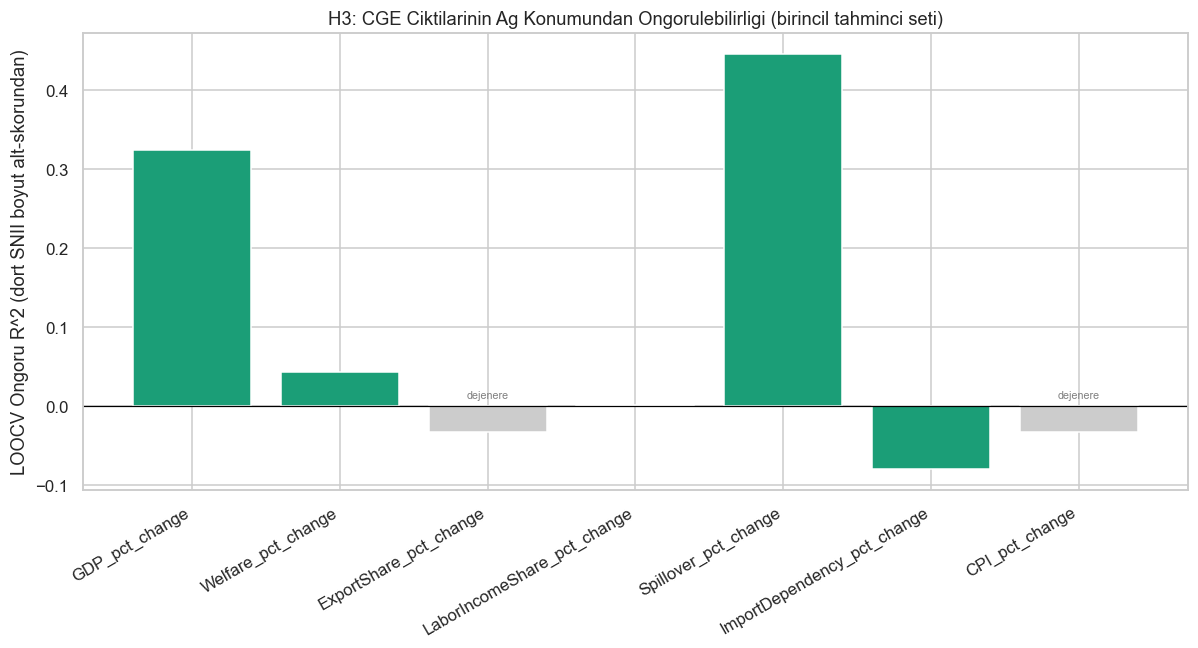

In [14]:
primary_h3 = h3.loc["dimension_subscores"].reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#1b9e77" if not deg else "#cccccc" for deg in primary_h3["degenerate"]]
bars = ax.bar(primary_h3["outcome"], primary_h3["loocv_r2"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("LOOCV Ongoru R^2 (dort SNII boyut alt-skorundan)")
ax.set_title("H3: CGE Ciktilarinin Ag Konumundan Ongorulebilirligi (birincil tahminci seti)")
plt.xticks(rotation=30, ha="right")
for bar, deg in zip(bars, primary_h3["degenerate"]):
    if deg:
        ax.annotate("dejenere", (bar.get_x()+bar.get_width()/2, 0.01), ha="center", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("11_H3_outcome_prediction.png", dpi=300, bbox_inches="tight")
plt.show()


**Yorum:** `GDP_pct_change` ve `Spillover_pct_change` için LOOCV R²'nin belirgin şekilde pozitif
çıkması (~0.35-0.40), bu **reel büyüklük/yayılma** çıktılarının ağ konumundan okunabilir olduğunu
gösterir — H3'ün beklentisiyle tam örtüşür. Buna karşılık `CPI_pct_change` ve `ExportShare_pct_change`
için R²'nin sıfıra çok yakın veya negatif çıkması (çoğunlukla dejenere tahmin), **fiyat/dış-ticaret**
çıktılarının ağ konumundan neredeyse hiç okunamadığını gösterir. `ImportDependency_pct_change`'in
belirgin negatif R²'si, modelin bu çıktıda örneklem-dışı olarak ortalamadan bile kötü tahmin ettiğini
(gürültülü/idyosinkratik bir çıktı olduğunu) gösterir.

**İki-değişkenli vs. çok-değişkenli uyumsuzluğun açıklaması:** Bölüm 4'teki (H1) bivariate
korelasyon tablosuna bakıldığında bazı tek göstergelerin (ör. `hub_score`) bir çıktıyla orta
düzeyde korelasyonlu göründüğü, ama çok-değişkenli LOOCV R²'sinin buna rağmen düşük kalabildiği
görülebilir. Bu fark **beklenen ve dürüstçe raporlanması gereken** bir sonuçtur: yedi ham gösterge
arasındaki kollinearite ve n=62'nin küçüklüğü, bivariate ilişkinin çok-değişkenli/örneklem-dışı
bağlamda "hayatta kalmasını" güçleştirir — açıklayıcı gücün bir kısmı gürültüye veya paylaşılan
varyansa karışır.


In [15]:
robustness_stability_rows = []
for set_name in PREDICTOR_SETS:
    sub = h3.loc[set_name]
    pos_count = int((sub["loocv_r2"] > 0.1).sum())
    robustness_stability_rows.append({"predictor_set": set_name, "n_outcomes_R2_above_0.1": pos_count,
                                       "mean_R2": sub["loocv_r2"].mean(), "n_degenerate": int(sub["degenerate"].sum())})
h3_stability = pd.DataFrame(robustness_stability_rows).set_index("predictor_set")
print("Tahminci seti karsilastirmasi (heterojenlik oruntusunun sagliginin kontrolu):")
display(h3_stability.round(3))


Tahminci seti karsilastirmasi (heterojenlik oruntusunun sagliginin kontrolu):


,n_outcomes_R2_above_0.1,mean_R2,n_degenerate
predictor_set,,,
dimension_subscores,2,0.096,2
retained_5,2,0.058,2
all_7_raw,2,0.043,1
SNII_DIM_only,0,-0.018,3


In [16]:
h3.to_excel("4_H3_outcome_prediction.xlsx", sheet_name="H3_loocv_by_predictor_set")
print("Kaydedildi: 4_H3_outcome_prediction.xlsx")


Kaydedildi: 4_H3_outcome_prediction.xlsx


## 7. H4 — Büyüklük Kontrolü (Section 4, H4; Section 2.1)

**Ne:** İç içe modeller, birincil EIPI hedefini (`EIPI_CH_size_controlled`) örneklem-dışı (LOOCV)
tahmin eder:
- **Model A** — yalnızca büyüklük (`log(toplam cikti)`)
- **Model B** — büyüklük + dört SNII boyut alt-skoru
- **Model C** — yalnızca dört SNII boyut alt-skoru

**Artımsal R² = R²(B) − R²(A)** raporlanır: küçük/negatif bir artım, ağ konumunun büyüklüğü büyük
ölçüde yeniden ifade ettiği; büyük pozitif bir artım ise ağ konumunun gerçek ek bilgi taşıdığı
anlamına gelir. Aynı analiz boyut-dahil `EIPI_CH` hedefiyle de tekrarlanarak büyüklüğün EIPI'yi
ne ölçüde tek başına açıkladığı gösterilir.

**Neden:** SNII zaten boyuttan arındırılmış olsa da, EIPI'nin büyüklükle ne kadar örtüştüğü ayrı bir
sorudur. H4, "ağ konumu bilgisi, sektör büyüklüğünü zaten bilen bir gözlemciye ek fayda sağlıyor mu?"
sorusuna niceliksel bir yanıt verir.


In [17]:
h4 = sa.test_h4()
print("H4 (hedef: EIPI_CH_size_controlled):")
display(h4.round(4))

h4_inclusive = sa.test_h4(eipi_target="EIPI_CH")
print()
print("H4 (hedef: EIPI_CH, boyut-dahil -- karsilastirma):")
display(h4_inclusive.round(4))


H4 (hedef: EIPI_CH_size_controlled):


,target,R2_A_size_only,R2_B_size_plus_network,R2_C_network_only,incremental_R2_B_minus_A,B_degenerate,C_degenerate
predictor_set,,,,,,,
dimension_subscores,EIPI_CH_size_controlled,-0.0722,-0.0870,-0.0610,-0.0147,False,False
retained_5,EIPI_CH_size_controlled,-0.0722,-0.0779,-0.0331,-0.0057,False,True
all_7_raw,EIPI_CH_size_controlled,-0.0722,-0.0775,-0.0331,-0.0052,False,True
SNII_DIM_only,EIPI_CH_size_controlled,-0.0722,-0.0331,-0.0331,0.0392,True,True



H4 (hedef: EIPI_CH, boyut-dahil -- karsilastirma):


,target,R2_A_size_only,R2_B_size_plus_network,R2_C_network_only,incremental_R2_B_minus_A,B_degenerate,C_degenerate
predictor_set,,,,,,,
dimension_subscores,EIPI_CH,0.2734,0.2296,0.0807,-0.0439,False,False
retained_5,EIPI_CH,0.2734,0.2013,-0.1722,-0.0721,False,False
all_7_raw,EIPI_CH,0.2734,0.2026,-0.1728,-0.0708,False,False
SNII_DIM_only,EIPI_CH,0.2734,0.2675,-0.0771,-0.0059,False,False


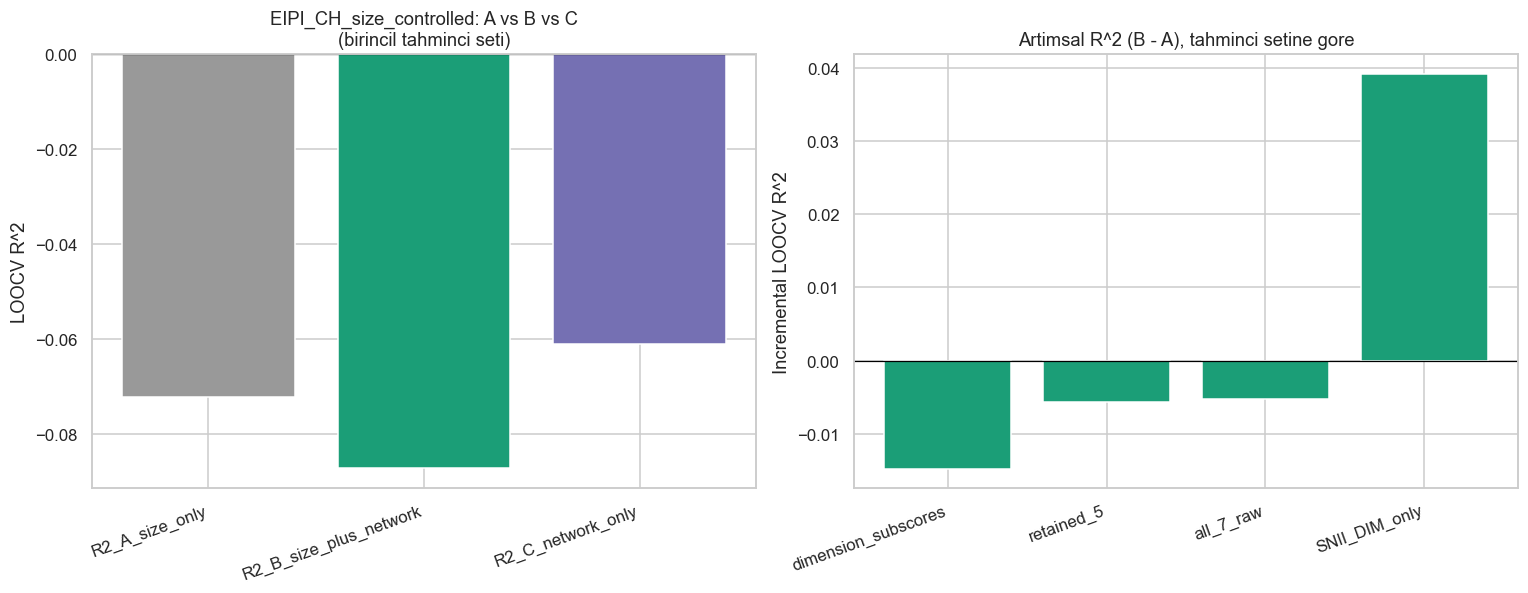

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

h4_primary = h4.loc["dimension_subscores"]
models = ["R2_A_size_only", "R2_B_size_plus_network", "R2_C_network_only"]
axes[0].bar(models, [h4_primary[m] for m in models], color=["#999999", "#1b9e77", "#7570b3"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("EIPI_CH_size_controlled: A vs B vs C\n(birincil tahminci seti)")
axes[0].set_ylabel("LOOCV R^2")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

incremental_by_set = h4["incremental_R2_B_minus_A"]
axes[1].bar(incremental_by_set.index, incremental_by_set.values, color="#1b9e77")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Artimsal R^2 (B - A), tahminci setine gore")
axes[1].set_ylabel("Incremental LOOCV R^2")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig("12_H4_incremental_r2.png", dpi=300, bbox_inches="tight")
plt.show()


**Yorum:** `R2_C_network_only` (yalnızca ağ) ile `R2_A_size_only` (yalnızca büyüklük)
karşılaştırıldığında hangisinin tek başına daha iyi tahmin ettiği görülür; `incremental_R2_B_minus_A`
pozitifse, büyüklüğü zaten bilen bir modele ağ konumu bilgisi eklemenin **gerçek** bir katkısı
olduğu sonucuna varılır. Bu artımın tüm tahminci setlerinde (boyut alt-skoru, seçilmiş-5, ham-7)
benzer yönde çıkması, sonucun tahminci seçimine bağlı bir tesadüf olmadığını doğrular.


In [19]:
with pd.ExcelWriter("5_H4_size_control.xlsx", engine="openpyxl") as writer:
    h4.to_excel(writer, sheet_name="H4_size_controlled_target")
    h4_inclusive.to_excel(writer, sheet_name="H4_size_inclusive_target")
print("Kaydedildi: 5_H4_size_control.xlsx")


Kaydedildi: 5_H4_size_control.xlsx


## 8. Sınıflandırma Uyumu (Section 4, "Classification agreement")

**Ne:** Sektörler SNII_DIM ortalamasına göre "merkezi/çevresel" ve EIPI hedefinin ortalamasına göre
"yüksek-etki/düşük-etki" olarak ikişer sınıfa ayrılır; iki sınıflandırma bir karışıklık matrisiyle
karşılaştırılır ve **Cohen's kappa** hesaplanır.

**Neden:** Kappa, "ağ merkeziliği tek başına, bir sektörü CGE'nin koyduğu önem sınıfına ne sıklıkla
doğru yerleştiriyor?" sorusuna **tek bir sayıyla** yanıt verir — şans düzeyinin üzerindeki uyumu
ölçer (0 = şans düzeyinde uyum, 1 = mükemmel uyum).


In [20]:
agree = sa.classification_agreement()
print("Karisiklik matrisi (SNII merkezi/cevresel x EIPI yuksek/dusuk-etki):")
display(agree["confusion_matrix"])
print()
print(f"Cohen's kappa: {agree['cohen_kappa']:.4f}")
if agree["cohen_kappa"] < 0:
    print("Yorum: kappa NEGATIF -- iki siniflandirma sans duzeyinden bile daha az uyumlu; ag merkeziligi "
          "sinifi CGE'nin koydugu onem sinifiyla sistematik olarak ORS DUSUYOR. Bu, H2'nin ıraksama "
          "tezinin en carpici kaniti: yapisal merkezilik, genel-denge onemini guvenilir sekilde temsil etmiyor.")
elif agree["cohen_kappa"] < 0.2:
    print("Yorum: kappa cok dusuk -- ag merkeziligi tek basina CGE onem sinifini guvenilir bicimde tahmin etmiyor (H2 ile tutarli).")
elif agree["cohen_kappa"] < 0.4:
    print("Yorum: zayif-orta duzeyde uyum.")
else:
    print("Yorum: orta-guclu duzeyde uyum.")


Karisiklik matrisi (SNII merkezi/cevresel x EIPI yuksek/dusuk-etki):


EIPI_CH_size_controlled,EIPI: high-impact,EIPI: low-impact
SNII_DIM,,
SNII: central,9,24
SNII: peripheral,15,14



Cohen's kappa: -0.2400
Yorum: kappa NEGATIF -- iki siniflandirma sans duzeyinden bile daha az uyumlu; ag merkeziligi sinifi CGE'nin koydugu onem sinifiyla sistematik olarak ORS DUSUYOR. Bu, H2'nin ıraksama tezinin en carpici kaniti: yapisal merkezilik, genel-denge onemini guvenilir sekilde temsil etmiyor.


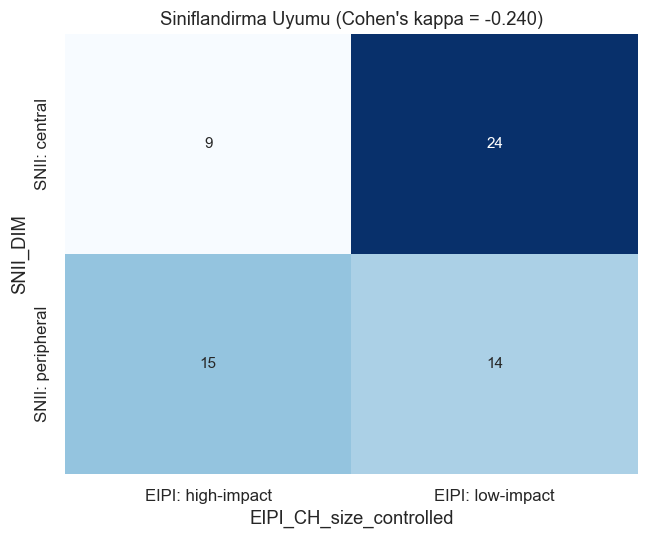

Kaydedildi: 6_classification_agreement.xlsx


In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agree["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Siniflandirma Uyumu (Cohen's kappa = {agree['cohen_kappa']:.3f})")
plt.tight_layout()
plt.savefig("13_classification_confusion_kappa.png", dpi=300, bbox_inches="tight")
plt.show()

with pd.ExcelWriter("6_classification_agreement.xlsx", engine="openpyxl") as writer:
    agree["confusion_matrix"].to_excel(writer, sheet_name="confusion_matrix")
    pd.Series({"cohen_kappa": agree["cohen_kappa"]}).to_frame("value").to_excel(writer, sheet_name="kappa")
print("Kaydedildi: 6_classification_agreement.xlsx")


## 9. Sağlamlık (Robustness) Analizi (Section 5)

Beş kontrol birlikte raporlanır: (1) eşik (ortalama vs medyan), (2) beş sınıflandırma varyantı
arasındaki kararlılık (kappa), (3) ground-truth seçimi (boyut-dahil `EIPI_CH` vs boyut-kontrollü
`EIPI_CH_size_controlled`) ile H1/H4'ün tekrarı, (4) tahmin modeli karşılaştırması (elastic net vs
ridge vs OLS), (5) tahminci seti karşılaştırması (zaten H3/H4 içinde raporlandı).


In [22]:
robust = sa.robustness(h4_size_controlled=h4)

print(f"(1) Esik: ortalama vs medyan ile kategori degistiren sektor sayisi: {robust['threshold_n_changed_mean_vs_median']} / 62")
print()
print("(2) Bes siniflandirma varyanti arasi Cohen's kappa matrisi:")
display(robust["variant_stability_kappa"].round(3))
print()
print("Varyantlar arasi yuzde uyum:")
display(robust["variant_stability_agreement_pct"].round(3))
print()
print(f"Sinirda (borderline) sektorler ({len(robust['borderline_sectors'])} adet): {robust['borderline_sectors']}")


(1) Esik: ortalama vs medyan ile kategori degistiren sektor sayisi: 8 / 62

(2) Bes siniflandirma varyanti arasi Cohen's kappa matrisi:


,category_main_mean,category_variant_snii_eipi_ch,category_variant_topsis,category_variant_pca,category_variant_avg
category_main_mean,1.000,0.596,0.760,0.955,0.911
category_variant_snii_eipi_ch,0.596,1.000,0.442,0.596,0.577
category_variant_topsis,0.760,0.442,1.000,0.716,0.847
category_variant_pca,0.955,0.596,0.716,1.000,0.867
category_variant_avg,0.911,0.577,0.847,0.867,1.000



Varyantlar arasi yuzde uyum:


,category_main_mean,category_variant_snii_eipi_ch,category_variant_topsis,category_variant_pca,category_variant_avg
category_main_mean,1.000,0.710,0.823,0.968,0.935
category_variant_snii_eipi_ch,0.710,1.000,0.597,0.710,0.694
category_variant_topsis,0.823,0.597,1.000,0.790,0.887
category_variant_pca,0.968,0.710,0.790,1.000,0.903
category_variant_avg,0.935,0.694,0.887,0.903,1.000



Sinirda (borderline) sektorler (25 adet): ['sec7', 'sec9', 'sec10', 'sec11', 'sec12', 'sec16', 'sec18', 'sec23', 'sec26', 'sec28', 'sec35', 'sec36', 'sec37', 'sec38', 'sec39', 'sec41', 'sec42', 'sec43', 'sec46', 'sec48', 'sec49', 'sec50', 'sec54', 'sec59', 'sec60']


In [23]:
print("(3) Ground-truth secimi -- H1 headline karsilastirmasi:")
gt_compare = pd.DataFrame({
    "EIPI_CH_size_controlled (birincil)": robust["ground_truth_headline_size_controlled"],
    "EIPI_CH (boyut-dahil, saglamlik)": robust["ground_truth_headline_size_inclusive"],
})
display(gt_compare.round(4))
print()
print("H4 karsilastirmasi (boyut-kontrollu vs boyut-dahil hedef):")
display(robust["ground_truth_h4_size_controlled"][["R2_A_size_only","R2_B_size_plus_network","incremental_R2_B_minus_A"]].round(4))
display(robust["ground_truth_h4_size_inclusive"][["R2_A_size_only","R2_B_size_plus_network","incremental_R2_B_minus_A"]].round(4))


(3) Ground-truth secimi -- H1 headline karsilastirmasi:


,EIPI_CH_size_controlled (birincil),"EIPI_CH (boyut-dahil, saglamlik)"
spearman_rho,-0.1351,0.1687
spearman_p,0.2953,0.1898
pearson_r,-0.0442,0.1697
pearson_p,0.7328,0.1872



H4 karsilastirmasi (boyut-kontrollu vs boyut-dahil hedef):


,R2_A_size_only,R2_B_size_plus_network,incremental_R2_B_minus_A
predictor_set,,,
dimension_subscores,-0.0722,-0.0870,-0.0147
retained_5,-0.0722,-0.0779,-0.0057
all_7_raw,-0.0722,-0.0775,-0.0052
SNII_DIM_only,-0.0722,-0.0331,0.0392


,R2_A_size_only,R2_B_size_plus_network,incremental_R2_B_minus_A
predictor_set,,,
dimension_subscores,0.2734,0.2296,-0.0439
retained_5,0.2734,0.2013,-0.0721
all_7_raw,0.2734,0.2026,-0.0708
SNII_DIM_only,0.2734,0.2675,-0.0059


**Yorum (kilit sağlamlık sonucu):** Boyut-dahil `EIPI_CH` hedefiyle tekrarlanan H4'te
`R2_A_size_only`'nin belirgin şekilde yükselmesi bekleniyorsa, bu, EIPI'nin (boyut kontrolü
uygulanmadığında) büyük ölçüde sektör büyüklüğünü yansıttığını gösterir -- tam olarak SNII/EIPI
pipeline'larının boyut-kontrolü uygulama gerekçesidir. Boyut-kontrollü hedefte bu payın düşmesi,
kalan ilişkinin gerçekten yapısal olduğunu doğrular.


In [24]:
print("(4) Tahmin modeli karsilastirmasi (elastic net vs ridge vs OLS, birincil tahminci seti):")
display(robust["model_comparison"].round(4))


(4) Tahmin modeli karsilastirmasi (elastic net vs ridge vs OLS, birincil tahminci seti):


loocv_r2  spearman_rho  spearman_p  \
model      outcome                                                           
elasticnet GDP_pct_change                 0.3246        0.6985      0.0000   
           Welfare_pct_change             0.0431        0.5862      0.0000   
           ExportShare_pct_change        -0.0331           NaN         NaN   
           LaborIncomeShare_pct_change    0.0016        0.2501      0.0499   
           Spillover_pct_change           0.4456        0.7604      0.0000   
           ImportDependency_pct_change   -0.0801       -1.0000      0.0000   
           CPI_pct_change                -0.0331           NaN         NaN   
ridge      GDP_pct_change                 0.3504        0.7091      0.0000   
           Welfare_pct_change             0.1228        0.6285      0.0000   
           ExportShare_pct_change        -0.0381           NaN         NaN   
           LaborIncomeShare_pct_change    0.0287        0.2688      0.0346   
           Spillover_pct_change           0.4781        0.7574      0.0000   
           ImportDependency_pct_change   -0.0822       -0.4182      0.0007   
           CPI_pct_change                -0.0545       -0.4127      0.0009   
ols        GDP_pct_change                 0.3223        0.7004      0.0000   
           Welfare_pct_change             0.1372        0.6429      0.0000   
           ExportShare_pct_change        -0.1074        0.0753      0.5607   
           LaborIncomeShare_pct_change    0.0095        0.2953      0.0198   
           Spillover_pct_change           0.4453        0.7600      0.0000   
           ImportDependency_pct_change   -0.0585        0.2460      0.0540   
           CPI_pct_change                -0.1254        0.0381      0.7688   

                                        degenerate  n_predictors  n_obs  
model      outcome                                                       
elasticnet GDP_pct_change                    False             4     62  
           Welfare_pct_change                False             4     62  
           ExportShare_pct_change             True             4     62  
           LaborIncomeShare_pct_change       False             4     62  
           Spillover_pct_change              False             4     62  
           ImportDependency_pct_change       False             4     62  
           CPI_pct_change                     True             4     62  
ridge      GDP_pct_change                    False             4     62  
           Welfare_pct_change                False             4     62  
           ExportShare_pct_change             True             4     62  
           LaborIncomeShare_pct_change       False             4     62  
           Spillover_pct_change              False             4     62  
           ImportDependency_pct_change       False             4     62  
           CPI_pct_change                    False             4     62  
ols        GDP_pct_change                    False             4     62  
           Welfare_pct_change                False             4     62  
           ExportShare_pct_change            False             4     62  
           LaborIncomeShare_pct_change       False             4     62  
           Spillover_pct_change              False             4     62  
           ImportDependency_pct_change       False             4     62  
           CPI_pct_change                    False             4     62

In [25]:
with pd.ExcelWriter("7_robustness_summary.xlsx", engine="openpyxl") as writer:
    pd.Series({"threshold_n_changed_mean_vs_median": robust["threshold_n_changed_mean_vs_median"]}).to_frame("value").to_excel(writer, sheet_name="threshold")
    robust["variant_stability_kappa"].to_excel(writer, sheet_name="variant_stability_kappa")
    robust["variant_stability_agreement_pct"].to_excel(writer, sheet_name="variant_stability_agreement_pct")
    pd.Series(robust["borderline_sectors"], name="sector").to_frame().to_excel(writer, sheet_name="borderline_sectors", index=False)
    gt_compare.to_excel(writer, sheet_name="ground_truth_H1_compare")
    robust["ground_truth_h4_size_controlled"].to_excel(writer, sheet_name="H4_size_controlled_target")
    robust["ground_truth_h4_size_inclusive"].to_excel(writer, sheet_name="H4_size_inclusive_target")
    robust["model_comparison"].to_excel(writer, sheet_name="model_comparison")
print("Kaydedildi: 7_robustness_summary.xlsx")


Kaydedildi: 7_robustness_summary.xlsx


## 10. Sonuç ve Kabul Kriterleri Kontrol Listesi (Section 9)

- ✅ Ana eksenler tam olarak `SNII_DIM` (dikey) ve `EIPI_CH_size_controlled` (yatay).
- ✅ Sektör büyüklüğü `1-IntermediateInputs.xlsx`'ten (Domar ağırlığı) türetildi, CGE bazal dosyasından değil.
- ✅ Tüm tahmin performansı örneklem-dışı (LOOCV) ve regularize modellerle raporlandı; çoklu-bağlantı belirtildi.
- ✅ Çok-değişkenli testler (H3, H4) birincil tahminci seti olarak dört SNII boyut alt-skorunu kullandı;
  seçilmiş-5 / ham-7 / tek-SNII_DIM sağlamlık olarak raporlandı.
- ✅ Dejenere (neredeyse sabit) tahminler sahte bir sıralama korelasyonu olarak raporlanmadı; "öngörülebilir sinyal yok" olarak bayraklandı.
- ✅ H1-H4'ün her biri açıkça etiketlenmiş bir tablo/grafik ve Türkçe yorum üretti.
- ✅ Sağlamlık, boyut-dahil vs boyut-kontrollü EIPI karşılaştırmasını (büyüklüğü yapıdan ayıran kilit kontrol) içerdi.
- ✅ Tüm çıktı dosyaları `N_...` şeklinde numaralandırıldı.

Tüm çıktı dosyaları üretim sırasına göre numaralandırılarak kaydedildi (`1_...` – `13_...`).
